In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

COMPONENTS = "3_comp"
REPORTS_DIR = os.path.join('cluster_dynamics_data', COMPONENTS, 'reports')
PLOTS_DIR = os.path.join('cluster_dynamics_data', COMPONENTS, 'plots')

os.makedirs(PLOTS_DIR, exist_ok=True)

CATEGORIES = ['income', 'prog']

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

REGION_EN = {
'Вінницька': 'Vinnytska obl.',
'Волинська': 'Volynska obl.',
'Дніпропетровська': 'Dnipropetrovska obl.',
'Донецька': 'Donetska obl.',
'Житомирська': 'Zhytomyrska obl.',
'Закарпатська': 'Zakarpatska obl.',
'Запорізька': 'Zaporizka obl.',
'Івано-Франківська': 'Ivano-Frankivska obl.',
'Київська': 'Kyivska obl.',
'Кіровоградська': 'Kirovohradska obl.',
'Луганська': 'Luhanska obl.',
'Львівська': 'Lvivska obl.',
'Миколаївська': 'Mykolaivska obl.',
'Одеська': 'Odeska obl.',
'Полтавська': 'Poltavska obl.',
'Рівненська': 'Rivnenska obl.',
'Сумська': 'Sumska obl.',
'Тернопільська': 'Ternopilska obl.',
'Харківська': 'Kharkivska obl.',
'Херсонська': 'Khersonska obl.',
'Хмельницька': 'Khmelnytska obl.',
'Черкаська': 'Cherkaska obl.',
'Чернівецька': 'Chernivetska obl.',
'Чернігівська': 'Chernihivska obl.'
}

CATEGORY_NAMES = {
    'income': 'Own Revenues',
    'prog': 'Program Expenses'
}

def get_hromadas_mapping(category):
    file_path = os.path.join(REPORTS_DIR, f'{category}_hromadas_per_region.csv')
    if not os.path.exists(file_path):
        return {}
    df = pd.read_csv(file_path)
    return dict(zip(df['region'], df['total_hromadas']))

def is_sequential(period_str):
    try:
        y1, y2 = period_str.split('-')
        return int(y2) - int(y1) == 1
    except:
        return False

def plot_all_combined_metrics_grid():
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(24, 16))
    handles, labels = None, None

    for j, cat in enumerate(CATEGORIES):
        hmap = get_hromadas_mapping(cat)
        if not hmap:
            continue
            
        cluster_file = os.path.join(REPORTS_DIR, f'{cat}_clusters_distribution.csv')
        if os.path.exists(cluster_file):
            df_c = pd.read_csv(cluster_file)
            cluster_cols = [c for c in df_c.columns if c.startswith('Cluster_')]
            df_c['active_clusters'] = (df_c[cluster_cols] > 0).sum(axis=1)
            df_c['total_hromadas'] = df_c['region'].map(hmap)
            df_c['active_clusters_norm'] = (df_c['active_clusters'] / df_c['total_hromadas']) * 100
            df_c['region_en'] = df_c['region'].map(lambda x: REGION_EN.get(x, x))
            df_c = df_c.sort_values('year')

            ax1 = axes[0, j]
            sns.lineplot(data=df_c, x='year', y='active_clusters_norm', hue='region_en', marker='o', linewidth=2, ax=ax1, legend=True)
            ax1.set_title(f'Cluster Fragmentation by Region ({CATEGORY_NAMES[cat]})\n(Active Clusters per 100 Hromadas)', fontsize=16)
            ax1.set_xlabel('Year', fontsize=12)
            ax1.set_ylabel('Fragmentation (%)', fontsize=12)
            ax1.set_xticks(df_c['year'].unique())
            
            if handles is None:
                handles, labels = ax1.get_legend_handles_labels()
            ax1.get_legend().remove()

        trans_file = os.path.join(REPORTS_DIR, f'{cat}_total_transitions.csv')
        if os.path.exists(trans_file):
            df_t = pd.read_csv(trans_file)
            df_t = df_t[df_t['period'].apply(is_sequential)]
            df_t['total_hromadas'] = df_t['region'].map(hmap)
            df_t['transitions_norm'] = (df_t['total_transitions'] / df_t['total_hromadas']) * 100
            df_t['region_en'] = df_t['region'].map(lambda x: REGION_EN.get(x, x))
            df_t = df_t.sort_values('period')

            ax2 = axes[1, j]
            sns.lineplot(data=df_t, x='period', y='transitions_norm', hue='region_en', marker='s', linewidth=2, ax=ax2, legend=False)
            ax2.set_title(f'Instability Dynamics: Hromadas Changing Clusters ({CATEGORY_NAMES[cat]})\n(% of Hromadas per Period)', fontsize=16)
            ax2.set_xlabel('Period', fontsize=12)
            ax2.set_ylabel('Hromadas with Transitions (%)', fontsize=12)
            ax2.tick_params(axis='x', rotation=45)

    if handles and labels:
        fig.legend(handles, labels, loc='lower center', ncol=8, bbox_to_anchor=(0.5, 0.01), title='Region', fontsize=11, title_fontsize=12)

    plt.subplots_adjust(top=0.95, bottom=0.12, left=0.04, right=0.98, hspace=0.25, wspace=0.12)
    out_path = os.path.join(PLOTS_DIR, 'all_metrics_combined_grid.png')
    plt.savefig(out_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.close()
    print(f"Saved 2x2 grid plot: {out_path}")

def save_top3_pivot(category):
    file_path = os.path.join(REPORTS_DIR, f'{category}_top3_transitions.csv')
    if not os.path.exists(file_path):
        return
        
    df = pd.read_csv(file_path)
    df = df[df['period'].apply(is_sequential)]
    
    periods = sorted(df['period'].unique())
    summary_rows = [] 
    
    for period in periods:
        period_df = df[df['period'] == period]
        regions = sorted(period_df['region'].unique())
        
        for region in regions:
            region_df = period_df[period_df['region'] == region].sort_values('rank')
            
            transitions_info = []
            for _, row in region_df.iterrows():
                t = f"{row['transition']} ({row['percent']}%)"
                transitions_info.append(t)
            
            combined_tops = "\n".join(transitions_info)
            if not combined_tops:
                combined_tops = "-"
            
            summary_rows.append({
                'Period': period,
                'Region': REGION_EN.get(region, region),
                'Transitions': combined_tops
            })
    
    if not summary_rows:
        return

    df_summary = pd.DataFrame(summary_rows)
    pivot_df = df_summary.pivot(index='Region', columns='Period', values='Transitions').reset_index()
    
    out_csv = os.path.join(REPORTS_DIR, f'{category}_top3_pivot_en.csv')
    pivot_df.to_csv(out_csv, index=False, encoding='utf-8-sig')
    print(f"Saved pivot table for {category}: {out_csv}")

print("Processing combined 2x2 grid plot...")
plot_all_combined_metrics_grid()

for cat in CATEGORIES:
    print(f"Processing pivot tables for {cat}...")
    save_top3_pivot(cat)

print("All files successfully saved.")

Processing combined 2x2 grid plot...
Saved 2x2 grid plot: cluster_dynamics_data/3_comp/plots/all_metrics_combined_grid.png
Processing pivot tables for income...
Saved pivot table for income: cluster_dynamics_data/3_comp/reports/income_top3_pivot_en.csv
Processing pivot tables for prog...
Saved pivot table for prog: cluster_dynamics_data/3_comp/reports/prog_top3_pivot_en.csv
All files successfully saved.


⏳ Processing and translating...
🎯 Target Object: Solonyanska Settlement Territorial Hromada


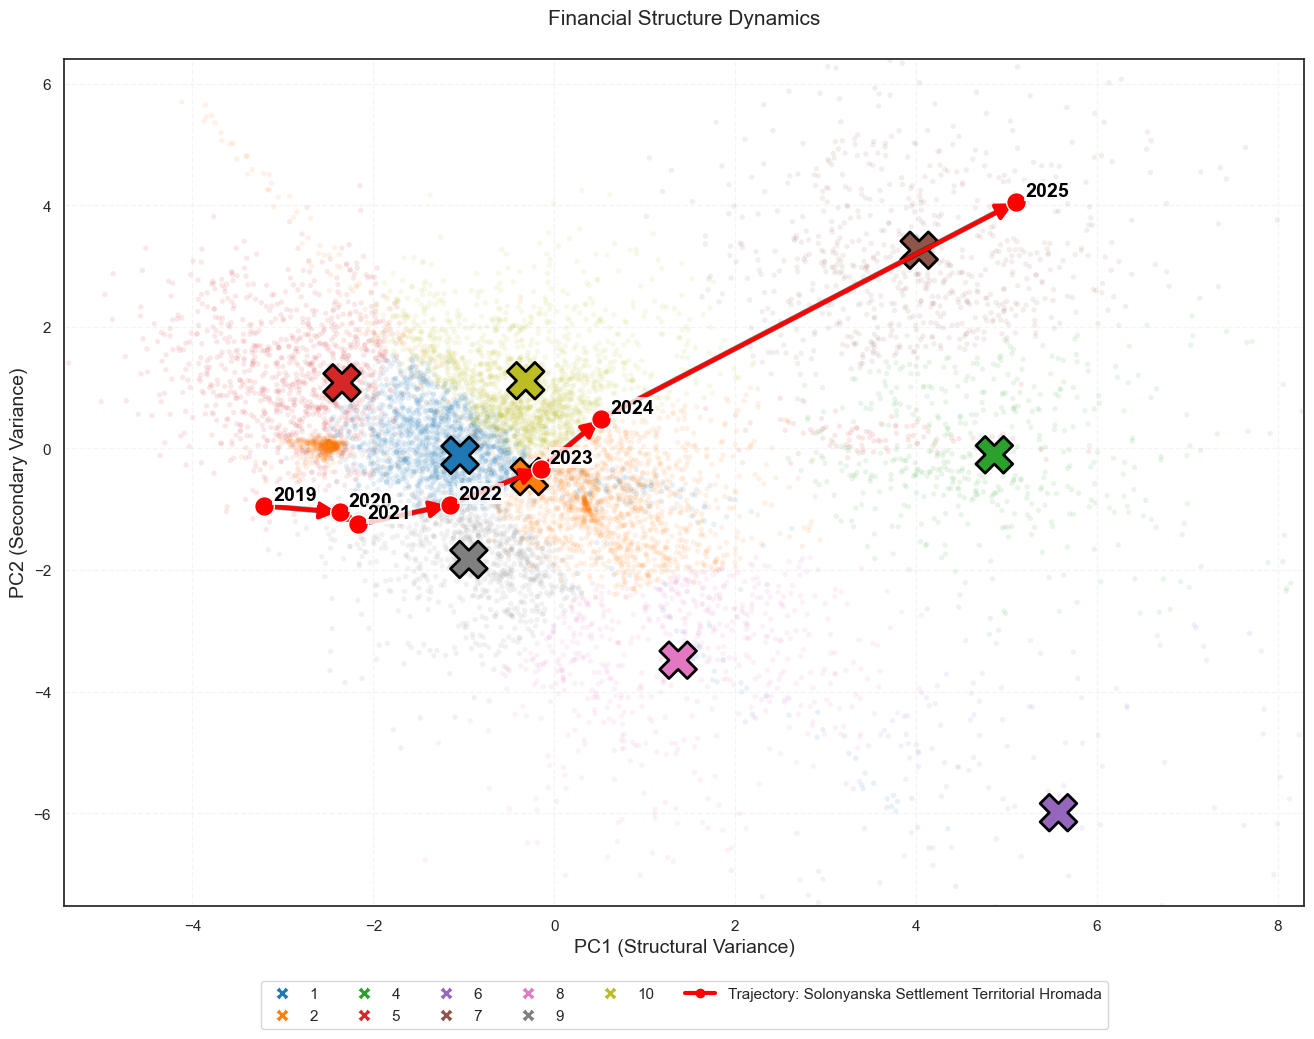

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from matplotlib.lines import Line2D

# --- PATH SETTINGS ---
PCA_JSON_PATH = '/Users/tempdelta/Desktop/budget/t_app/viz_dashboard_data2/pca_t_data/3_comp/trajectories/traj_income.json'
CLUSTER_JSON_PATH = '/Users/tempdelta/Desktop/budget/t_app/viz_dashboard_data2/pca_t_data/3_comp/clusters/clusters_income.json'

def load_and_merge_data():
    with open(PCA_JSON_PATH, 'r', encoding='utf-8') as f:
        pca_data = json.load(f)['trajectories']
    with open(CLUSTER_JSON_PATH, 'r', encoding='utf-8') as f:
        cluster_data = json.load(f)

    all_records = []
    lookup = {}

    for level in ['l1', 'l2', 'l3']:
        lvl_content = cluster_data.get(level, {})
        for year_str, codes_dict in lvl_content.items():
            if not isinstance(codes_dict, dict): continue
            year_int = int(year_str)
            if year_int == 2018: continue
            for b_code, val in codes_dict.items():
                clean_code = str(b_code).lstrip('0')
                cluster_val = val.get('cluster', list(val.values())[0]) if isinstance(val, dict) else val
                lookup[(clean_code, year_int)] = cluster_val

    for b_code, b_info in pca_data.items():
        clean_code = str(b_code).lstrip('0')
        h_name = b_info.get('name', b_code)
        
        # Translate the specific target name if found
        if "Солонянської" in h_name:
            h_name = "Solonyanska Settlement Territorial Hromada"
            
        dates = b_info.get('dates', [])
        pc1_list = b_info.get('pc1', [])
        pc2_list = b_info.get('pc2', [])
        for i in range(len(dates)):
            try:
                date_val = dates[i]
                year = int(date_val.split('.')[1]) if '.' in date_val else int(date_val)
                if year == 2018: continue
                cluster_label = lookup.get((clean_code, year))
                if cluster_label is not None:
                    all_records.append({
                        'budget_code': b_code, 'name': h_name, 'year': year,
                        'pc1': pc1_list[i], 'pc2': pc2_list[i], 'cluster': str(cluster_label)
                    })
            except: continue
                
    if not all_records: return pd.DataFrame()
    df = pd.DataFrame(all_records)
    return df.groupby(['budget_code', 'name', 'year', 'cluster'], as_index=False)[['pc1', 'pc2']].mean()

def find_most_volatile(df):
    df_sorted = df.sort_values(['budget_code', 'year'])
    df_sorted['prev_cluster'] = df_sorted.groupby('budget_code')['cluster'].shift(1)
    df_sorted['changed'] = (df_sorted['cluster'] != df_sorted['prev_cluster']) & df_sorted['prev_cluster'].notna()
    volatility = df_sorted.groupby(['budget_code', 'name'])['changed'].sum().reset_index()
    top_obj = volatility.loc[volatility['changed'].idxmax()]
    return top_obj['budget_code'], top_obj['name']

def run_visualization():
    print("⏳ Processing and translating...")
    df = load_and_merge_data()
    if df.empty: return

    target_code, target_name = find_most_volatile(df)
    
    # Ensure the English name is used for the specific target
    if "Солонянської" in target_name:
        target_name = "Solonyanska Settlement Territorial Hromada"

    print(f"🎯 Target Object: {target_name}")
    
    centroids = df.groupby('cluster')[['pc1', 'pc2']].mean().reset_index()
    df_target = df[df['budget_code'] == target_code].sort_values('year')

    plt.figure(figsize=(16, 11))
    sns.set_theme(style="white")
    
    unique_clusters = sorted(df['cluster'].unique(), key=lambda x: int(x) if x.isdigit() else x)
    palette = sns.color_palette("tab10", len(unique_clusters))
    color_map = dict(zip(unique_clusters, palette))

    # Calculate limits with robust scaling
    x_min, x_max = np.percentile(df['pc1'], [1, 99])
    y_min, y_max = np.percentile(df['pc2'], [1, 99])
    pad_x, pad_y = (x_max - x_min) * 0.15, (y_max - y_min) * 0.15
    plt.xlim(x_min - pad_x, x_max + pad_x)
    plt.ylim(y_min - pad_y, y_max + pad_y)

    # 1. Background (Nationwide)
    sns.scatterplot(
        data=df, x='pc1', y='pc2', hue='cluster', 
        palette=color_map, s=15, alpha=0.1, edgecolor='none', legend=False
    )
    
    # 2. Centroids (Drawn as large 'X' but labels handled in custom legend)
    sns.scatterplot(
        data=centroids, x='pc1', y='pc2', hue='cluster', 
        palette=color_map, s=700, marker='X', edgecolor='black', linewidth=2, legend=False
    )

    # 3. Trajectory
    plt.plot(df_target['pc1'], df_target['pc2'], color='black', linewidth=4, zorder=30, alpha=0.5)
    plt.plot(df_target['pc1'], df_target['pc2'], color='red', linewidth=2.5, zorder=31)
    
    for i in range(len(df_target)):
        row = df_target.iloc[i]
        plt.scatter(row['pc1'], row['pc2'], color='red', s=200, edgecolor='white', zorder=32)
        plt.text(
            row['pc1'] + 0.1, row['pc2'] + 0.1, str(int(row['year'])), 
            fontsize=14, fontweight='bold', color='black', zorder=33,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
        )
        
        if i < len(df_target) - 1:
            next_row = df_target.iloc[i+1]
            plt.annotate('', xy=(next_row['pc1'], next_row['pc2']), xytext=(row['pc1'], row['pc2']),
                         arrowprops=dict(arrowstyle='-|>', color='red', lw=3, mutation_scale=25), zorder=31)

    # --- CUSTOM LEGEND LOGIC ---
    # Creating legend items for clusters as crosses (X)
    cluster_handles = [
        Line2D([0], [0], marker='X', color='w', markerfacecolor=color_map[c], 
               markersize=10, label=c, linestyle='None') 
        for c in unique_clusters
    ]
    
    # Trajectory entry
    trajectory_handle = [Line2D([0], [0], color='red', lw=3, marker='o', label=f'Trajectory: {target_name}')]
    
    # Final Legend at the bottom
    plt.legend(
        handles=cluster_handles + trajectory_handle, 
        loc='upper center', bbox_to_anchor=(0.5, -0.08),
        ncol=6, 
        frameon=True, fontsize=11
    )

    plt.title(f"Financial Structure Dynamics", fontsize=15, pad=25)
    plt.xlabel("PС1 (Structural Variance)", fontsize=14)
    plt.ylabel("PС2 (Secondary Variance)", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.2)
    
    out_dir = 'trajectories_plots'
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(os.path.join(out_dir, f'final_english_trajectory_{target_code}.png'), dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == '__main__':
    run_visualization()

In [16]:
import pandas as pd
import json
import os
import math

PCA_JSON_PATH = '/Users/tempdelta/Desktop/budget/t_app/viz_dashboard_data2/pca_t_data/3_comp/trajectories/traj_income.json'
CLUSTER_JSON_PATH = '/Users/tempdelta/Desktop/budget/t_app/viz_dashboard_data2/pca_t_data/3_comp/clusters/clusters_income.json'

def analyze_overall_top_per_cluster():
    if not os.path.exists(PCA_JSON_PATH) or not os.path.exists(CLUSTER_JSON_PATH):
        print("Files not found.")
        return

    with open(PCA_JSON_PATH, 'r', encoding='utf-8') as f:
        traj_data = json.load(f)
    with open(CLUSTER_JSON_PATH, 'r', encoding='utf-8') as f:
        clust_data = json.load(f)

    metadata = traj_data.get('metadata', {}).get('l3', {})
    
    records = []
    for code, info in traj_data['trajectories'].items():
        if info['level'] != 'l3': continue
        pc_keys = [k for k in info.keys() if k.startswith('pc')]
        for i, date_str in enumerate(info['dates']):
            year = date_str.split('.')[1]
            if year in clust_data.get('l3', {}) and code in clust_data['l3'][year]:
                row = {'cluster': clust_data['l3'][year][code]['cluster']}
                for pc in pc_keys:
                    row[pc] = info[pc][i]
                records.append(row)

    df = pd.DataFrame(records)
    centroids = df.groupby('cluster').mean()

    unique_clusters = sorted(df['cluster'].unique(), key=lambda x: int(x) if str(x).isdigit() else x)

    for cid in unique_clusters:
        if cid not in centroids.index: continue
        
        print(f"\nCLUSTER {cid}")
        print("-" * 30)
        
        feature_impacts = {}

        for pc_col in centroids.columns:
            centroid_val = centroids.loc[cid, pc_col]
            pc_name = pc_col.upper()
            
            if abs(centroid_val) < 0.4:
                continue
                
            direction = 'positive' if centroid_val > 0 else 'negative'
            
            factors = [f for f in metadata.get(pc_name, []) if f['direction'] == direction]
            
            for f in factors:
                code = f['code']
                name = f['name']
                weight = f['weight']
                
                impact = abs(weight * centroid_val)
                
                key = f"[{code}] {name}"
                if key in feature_impacts:
                    feature_impacts[key] += impact
                else:
                    feature_impacts[key] = impact

        sorted_features = sorted(feature_impacts.items(), key=lambda item: item[1], reverse=True)

        for i, (key, impact) in enumerate(sorted_features[:5], 1):
            print(f"   {i:2}. {key} | Total Impact: {impact:.4f}")

if __name__ == "__main__":
    analyze_overall_top_per_cluster()


CLUSTER 1
------------------------------

CLUSTER 2
------------------------------
    1. [41036300] Субвенція з державного бюджету місцевим бюджетам на здійснення доплат педагогічним працівникам закладів загальної середньої освіти | Total Impact: 0.1628
    2. [41036000] Субвенція з державного бюджету місцевим бюджетам на реалізацію публічного інвестиційного проекту на забезпечення якісної, сучасної та доступної загальної середньої освіти «Нова українська школа» | Total Impact: 0.1580
    3. [11010100] Податок на доходи фізичних осіб, що сплачується податковими агентами, із доходів платника податку у вигляді заробітної плати | Total Impact: 0.1563
    4. [41035400] Субвенція з державного бюджету місцевим бюджетам на надання державної підтримки особам з особливими освітніми потребами | Total Impact: 0.1548
    5. [14040100] Акцизний податок з реалізації виробниками та/або імпортерами, у тому числі в роздрібній торгівлі тютюнових виробів, тютюну та промислових замінників тютюну, рідин,

In [17]:
import pandas as pd
import json
import os

PCA_JSON_PATH = '/Users/tempdelta/Desktop/budget/t_app/viz_dashboard_data2/pca_t_data/3_comp/trajectories/traj_income.json'
CLUSTER_JSON_PATH = '/Users/tempdelta/Desktop/budget/t_app/viz_dashboard_data2/pca_t_data/3_comp/clusters/clusters_income.json'

def load_and_merge_data():
    with open(PCA_JSON_PATH, 'r', encoding='utf-8') as f:
        pca_data = json.load(f)['trajectories']
    with open(CLUSTER_JSON_PATH, 'r', encoding='utf-8') as f:
        cluster_data = json.load(f)

    all_records = []
    lookup = {}

    for level in ['l1', 'l2', 'l3']:
        lvl_content = cluster_data.get(level, {})
        for year_str, codes_dict in lvl_content.items():
            if not isinstance(codes_dict, dict): continue
            year_int = int(year_str)
            if year_int == 2018: continue
            for b_code, val in codes_dict.items():
                clean_code = str(b_code).lstrip('0')
                cluster_val = val.get('cluster', list(val.values())[0]) if isinstance(val, dict) else val
                lookup[(clean_code, year_int)] = cluster_val

    for b_code, b_info in pca_data.items():
        clean_code = str(b_code).lstrip('0')
        h_name = b_info.get('name', b_code)
        dates = b_info.get('dates', [])
        for i in range(len(dates)):
            try:
                date_val = dates[i]
                year = int(date_val.split('.')[1]) if '.' in date_val else int(date_val)
                if year == 2018: continue
                cluster_label = lookup.get((clean_code, year))
                if cluster_label is not None:
                    all_records.append({
                        'budget_code': b_code, 'name': h_name, 'year': year,
                        'cluster': str(cluster_label)
                    })
            except: continue
                
    if not all_records: return pd.DataFrame()
    return pd.DataFrame(all_records)

def get_cluster_stats():
    df = load_and_merge_data()
    if df.empty: 
        print("No data found")
        return

    latest_records = df.sort_values('year').groupby('budget_code').last().reset_index()
    
    stats = latest_records.groupby('cluster')['budget_code'].count().reset_index()
    stats.columns = ['Cluster', 'Hromadas Count']
    
    total = stats['Hromadas Count'].sum()
    stats['Percentage (%)'] = (stats['Hromadas Count'] / total * 100).round(2)
    
    stats = stats.sort_values('Cluster', key=lambda x: x.astype(int))
    
    print("\nCluster Distribution (Based on latest available year):")
    print(stats.to_string(index=False))
    print(f"\nTotal unique hromadas: {total}")

if __name__ == '__main__':
    get_cluster_stats()


Cluster Distribution (Based on latest available year):
Cluster  Hromadas Count  Percentage (%)
      1               2            0.13
      2             232           14.81
      4             355           22.67
      6              54            3.45
      7             719           45.91
      8              11            0.70
     10             193           12.32

Total unique hromadas: 1566


📊 4-панельний графік успішно збережено у: metrics_output/final_4x_grid_accuracy.png


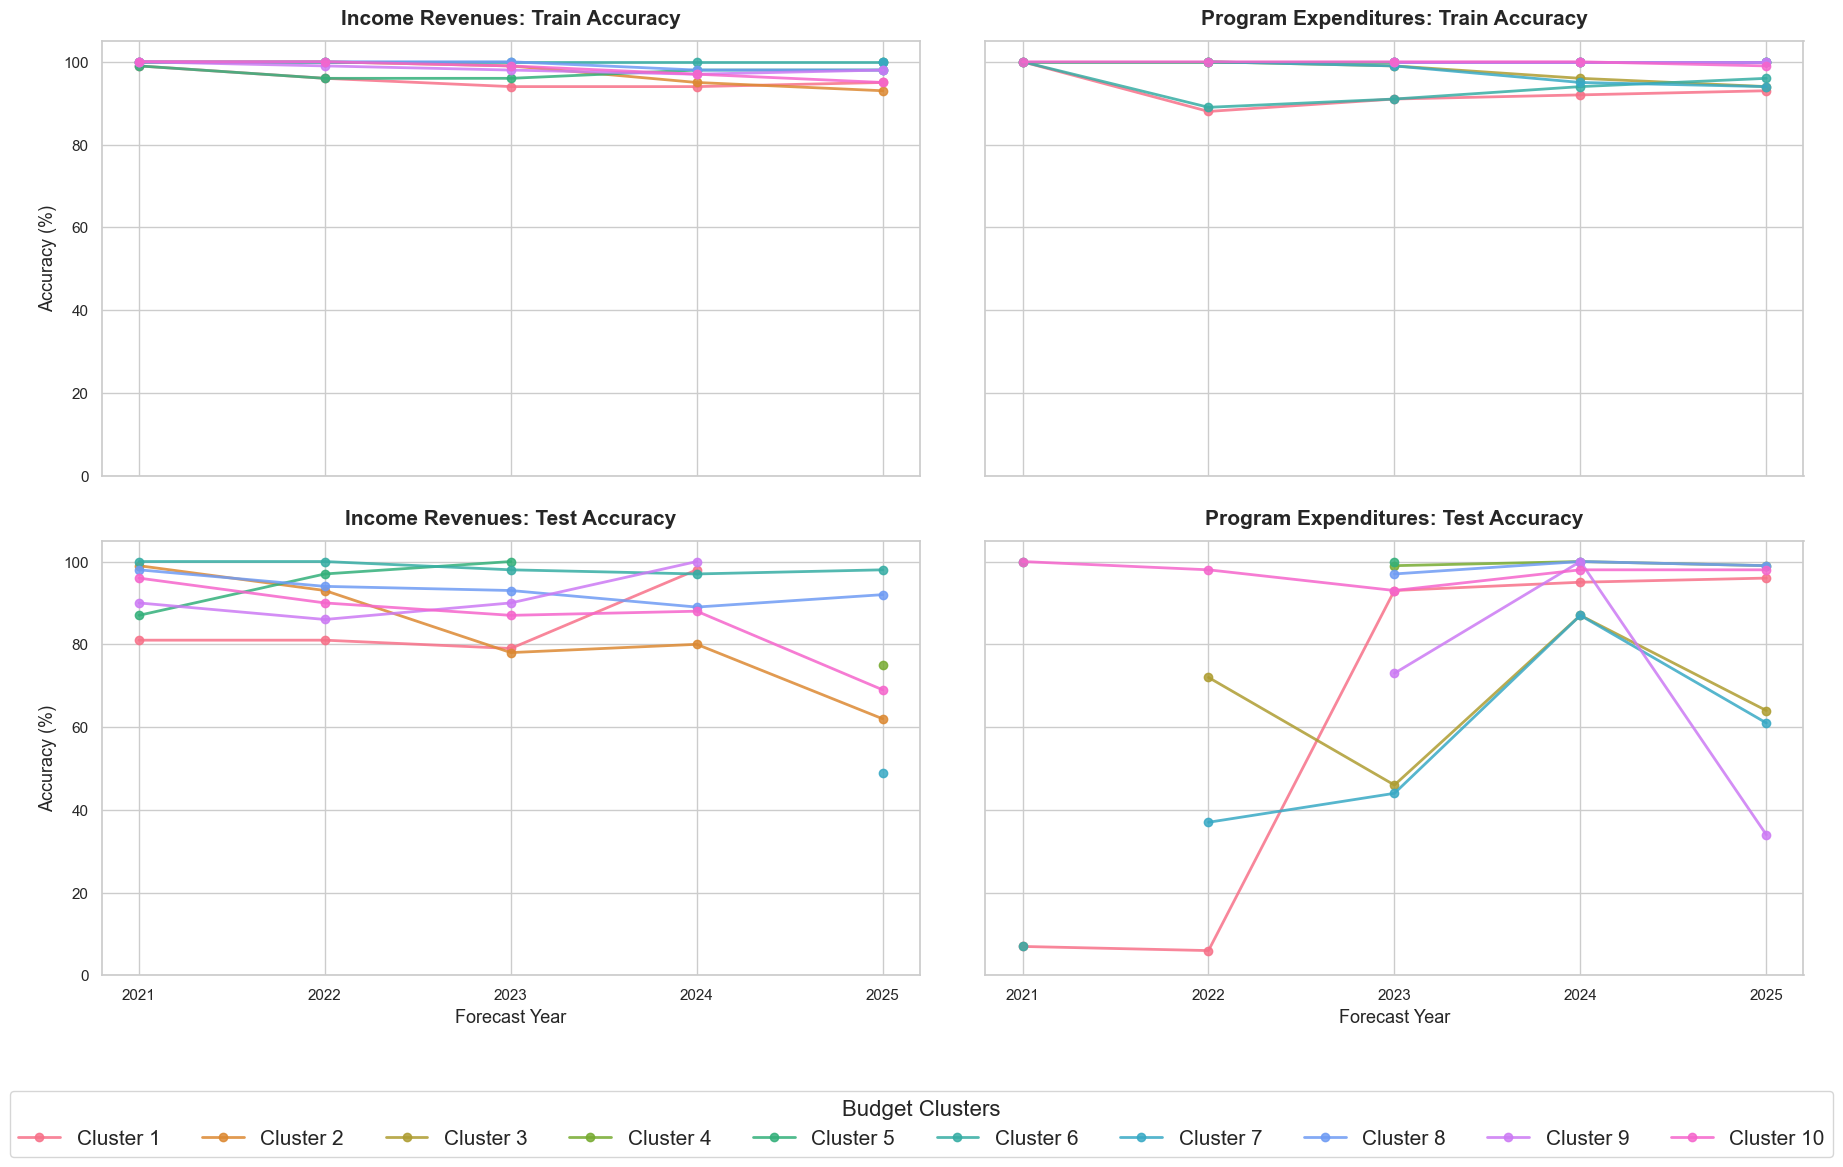

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- НАЛАШТУВАННЯ ---
METRICS_DIR = "metrics_output"
CATEGORIES = ['income', 'prog']
DATASETS = ['train', 'test']

def load_and_clean_data(category, dataset):
    filepath = os.path.join(METRICS_DIR, f'cluster_accuracy_{dataset}_yearly_{category}.csv')
    if not os.path.exists(filepath):
        print(f"⚠️ Файл не знайдено: {filepath}")
        return None
    
    df = pd.read_csv(filepath)
    for col in df.columns:
        if col != 'Forecast_Year':
            df[col] = df[col].astype(str).str.replace('%', '', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    rename_dict = {col: col.replace("Кл.", "Cluster") for col in df.columns if "Кл." in col}
    df = df.rename(columns=rename_dict)
    return df

def plot_4x_grid():
    data_dict = {}
    all_clusters = set()
    
    for cat in CATEGORIES:
        for ds in DATASETS:
            df = load_and_clean_data(cat, ds)
            if df is not None:
                data_dict[f"{cat}_{ds}"] = df
                cols = [c for c in df.columns if c != 'Forecast_Year']
                all_clusters.update(cols)
                
    if not data_dict:
        print("❌ Немає даних для побудови графіка.")
        return

    sorted_clusters = sorted(list(all_clusters), key=lambda x: int(x.replace("Cluster ", "")))
    palette = sns.color_palette("husl", len(sorted_clusters))
    color_map = dict(zip(sorted_clusters, palette))

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12), sharex=True, sharey=True)
    
    titles = {
        'income_train': 'Income Revenues: Train Accuracy',
        'income_test':  'Income Revenues: Test Accuracy',
        'prog_train':   'Program Expenditures: Train Accuracy',
        'prog_test':    'Program Expenditures: Test Accuracy'
    }

    plot_positions = {
        'income_train': axes[0, 0],
        'income_test':  axes[1, 0],
        'prog_train':   axes[0, 1],
        'prog_test':    axes[1, 1]
    }

    lines_for_legend = {}

    for key, ax in plot_positions.items():
        if key not in data_dict:
            ax.set_visible(False)
            continue
            
        df = data_dict[key]
        years = df['Forecast_Year'].astype(int).tolist()
        
        clusters_in_df = [c for c in df.columns if c != 'Forecast_Year']
        clusters_in_df = sorted(clusters_in_df, key=lambda x: int(x.replace("Cluster ", "")))
        
        for col in clusters_in_df:
            line, = ax.plot(df['Forecast_Year'], df[col], 
                            marker='o', linewidth=2, markersize=6, 
                            label=col, color=color_map[col], alpha=0.85)
            if col not in lines_for_legend:
                lines_for_legend[col] = line
                
        ax.set_title(titles[key], fontsize=15, pad=12, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.set_xticks(years)
        
        if key in ['income_test', 'prog_test']:
            ax.set_xlabel('Forecast Year', fontsize=13)
        if key in ['income_train', 'income_test']:
            ax.set_ylabel('Accuracy (%)', fontsize=13)

    labels = sorted(lines_for_legend.keys(), key=lambda x: int(x.replace("Cluster ", "")))
    handles = [lines_for_legend[l] for l in labels]
    
    # --- ОСЬ ТУТ ЗБІЛЬШЕНО ШРИФТ ЛЕГЕНДИ ---
    # Збільшено fontsize до 15 та додано title_fontsize=16
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), 
               ncol=min(10, len(labels)), fontsize=15, title_fontsize=16, 
               frameon=True, title="Budget Clusters")

    # --- ТУТ ЗБІЛЬШЕНО ВІДСТУП ЗНИЗУ ---
    # Збільшено bottom до 0.18, щоб велика легенда помістилася
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18, hspace=0.15, wspace=0.08)
    
    output_path = os.path.join(METRICS_DIR, 'final_4x_grid_accuracy.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"📊 4-панельний графік успішно збережено у: {output_path}")
    
    plt.show()

if __name__ == "__main__":
    plot_4x_grid()

4-панельний графік успішно збережено у: metrics_output/final_4x_grid_f1.png


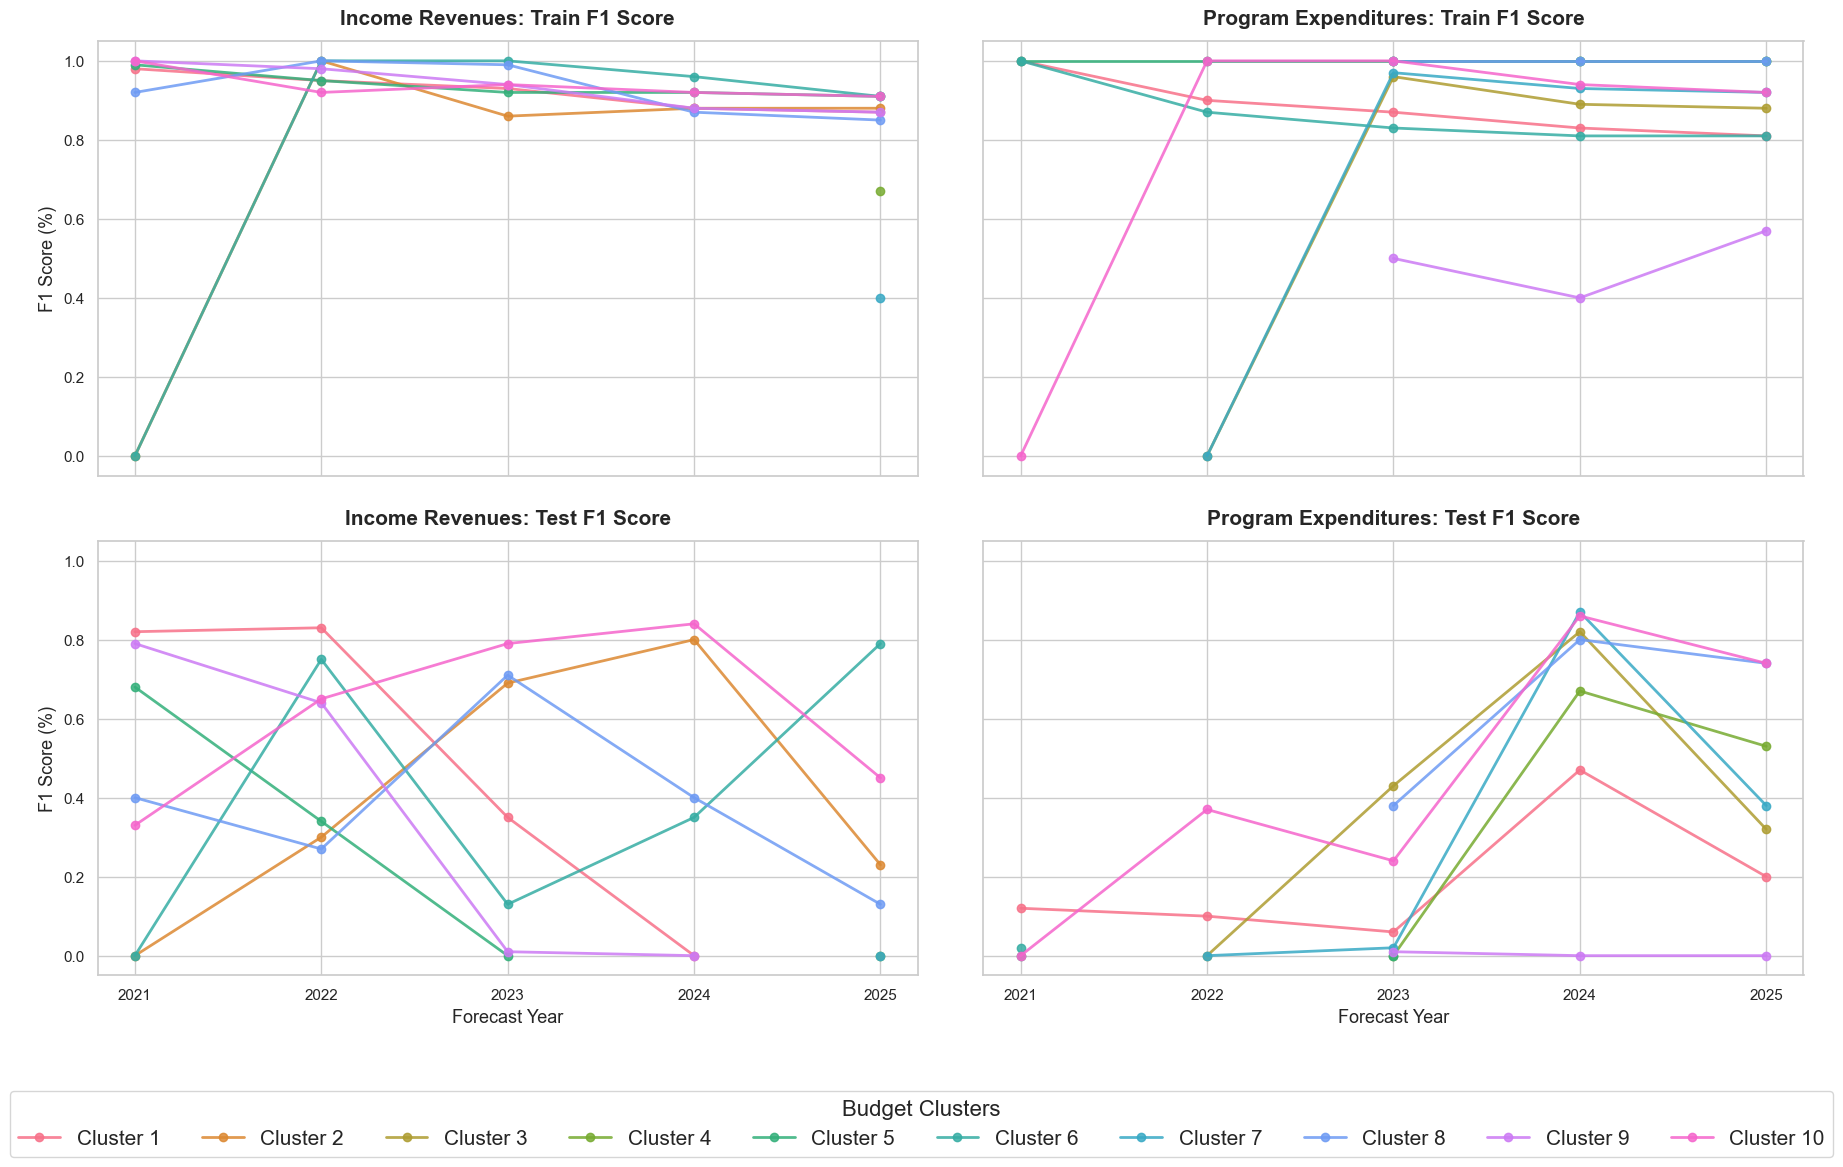

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

METRICS_DIR = "metrics_output"
CATEGORIES = ['income', 'prog']
DATASETS = ['train', 'test']
FILE_PREFIX = "cluster_f1-score"

def load_and_clean_data(category, dataset):
    filepath = os.path.join(METRICS_DIR, f'{FILE_PREFIX}_{dataset}_yearly_{category}.csv')
    if not os.path.exists(filepath):
        print(f"Файл не знайдено: {filepath}")
        return None
    
    df = pd.read_csv(filepath)
    for col in df.columns:
        if col != 'Forecast_Year':
            df[col] = df[col].astype(str).str.replace('%', '', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    rename_dict = {col: col.replace("Кл.", "Cluster") for col in df.columns if "Кл." in col}
    df = df.rename(columns=rename_dict)
    return df

def plot_4x_grid():
    data_dict = {}
    all_clusters = set()
    
    for cat in CATEGORIES:
        for ds in DATASETS:
            df = load_and_clean_data(cat, ds)
            if df is not None:
                data_dict[f"{cat}_{ds}"] = df
                cols = [c for c in df.columns if c != 'Forecast_Year']
                all_clusters.update(cols)
                
    if not data_dict:
        print("Немає даних для побудови графіка.")
        return

    sorted_clusters = sorted(list(all_clusters), key=lambda x: int(x.replace("Cluster ", "")))
    palette = sns.color_palette("husl", len(sorted_clusters))
    color_map = dict(zip(sorted_clusters, palette))

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12), sharex=True, sharey=True)
    
    titles = {
        'income_train': 'Income Revenues: Train F1 Score',
        'income_test':  'Income Revenues: Test F1 Score',
        'prog_train':   'Program Expenditures: Train F1 Score',
        'prog_test':    'Program Expenditures: Test F1 Score'
    }

    plot_positions = {
        'income_train': axes[0, 0],
        'income_test':  axes[1, 0],
        'prog_train':   axes[0, 1],
        'prog_test':    axes[1, 1]
    }

    lines_for_legend = {}

    for key, ax in plot_positions.items():
        if key not in data_dict:
            ax.set_visible(False)
            continue
            
        df = data_dict[key]
        years = df['Forecast_Year'].astype(int).tolist()
        
        clusters_in_df = [c for c in df.columns if c != 'Forecast_Year']
        clusters_in_df = sorted(clusters_in_df, key=lambda x: int(x.replace("Cluster ", "")))
        
        for col in clusters_in_df:
            line, = ax.plot(df['Forecast_Year'], df[col], 
                            marker='o', linewidth=2, markersize=6, 
                            label=col, color=color_map[col], alpha=0.85)
            if col not in lines_for_legend:
                lines_for_legend[col] = line
                
        ax.set_title(titles[key], fontsize=15, pad=12, fontweight='bold')
        ax.set_ylim(-0.05, 1.05) # ЗМІНЕНО МАСШТАБ ДЛЯ ДРОБІВ
        ax.set_xticks(years)
        
        if key in ['income_test', 'prog_test']:
            ax.set_xlabel('Forecast Year', fontsize=13)
        if key in ['income_train', 'income_test']:
            ax.set_ylabel('F1 Score (%)', fontsize=13)

    labels = sorted(lines_for_legend.keys(), key=lambda x: int(x.replace("Cluster ", "")))
    handles = [lines_for_legend[l] for l in labels]
    
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), 
               ncol=min(10, len(labels)), fontsize=15, title_fontsize=16, 
               frameon=True, title="Budget Clusters")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18, hspace=0.15, wspace=0.08)
    
    output_path = os.path.join(METRICS_DIR, 'final_4x_grid_f1.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"4-панельний графік успішно збережено у: {output_path}")
    
    plt.show()

if __name__ == "__main__":
    plot_4x_grid()

=== DATA FOR PLOTS ===
Category  Components  Year     Region  Local_Explained_Var
  income           3  2018   Donetska             3.776750
  income           3  2019   Donetska             4.829792
  income           3  2020   Donetska             4.063550
  income           3  2021   Donetska             1.220257
  income           3  2022   Donetska             0.725293
  income           3  2023   Donetska             0.617663
  income           3  2024   Donetska             0.457068
  income           3  2025   Donetska             0.517208
  income           3  2018 Kharkivska             4.773917
  income           3  2019 Kharkivska             3.046198
  income           3  2020 Kharkivska             3.021472
  income           3  2021 Kharkivska             2.117536
  income           3  2022 Kharkivska             1.787440
  income           3  2023 Kharkivska             1.235000
  income           3  2024 Kharkivska             1.520506
  income           3  2025 Kharki

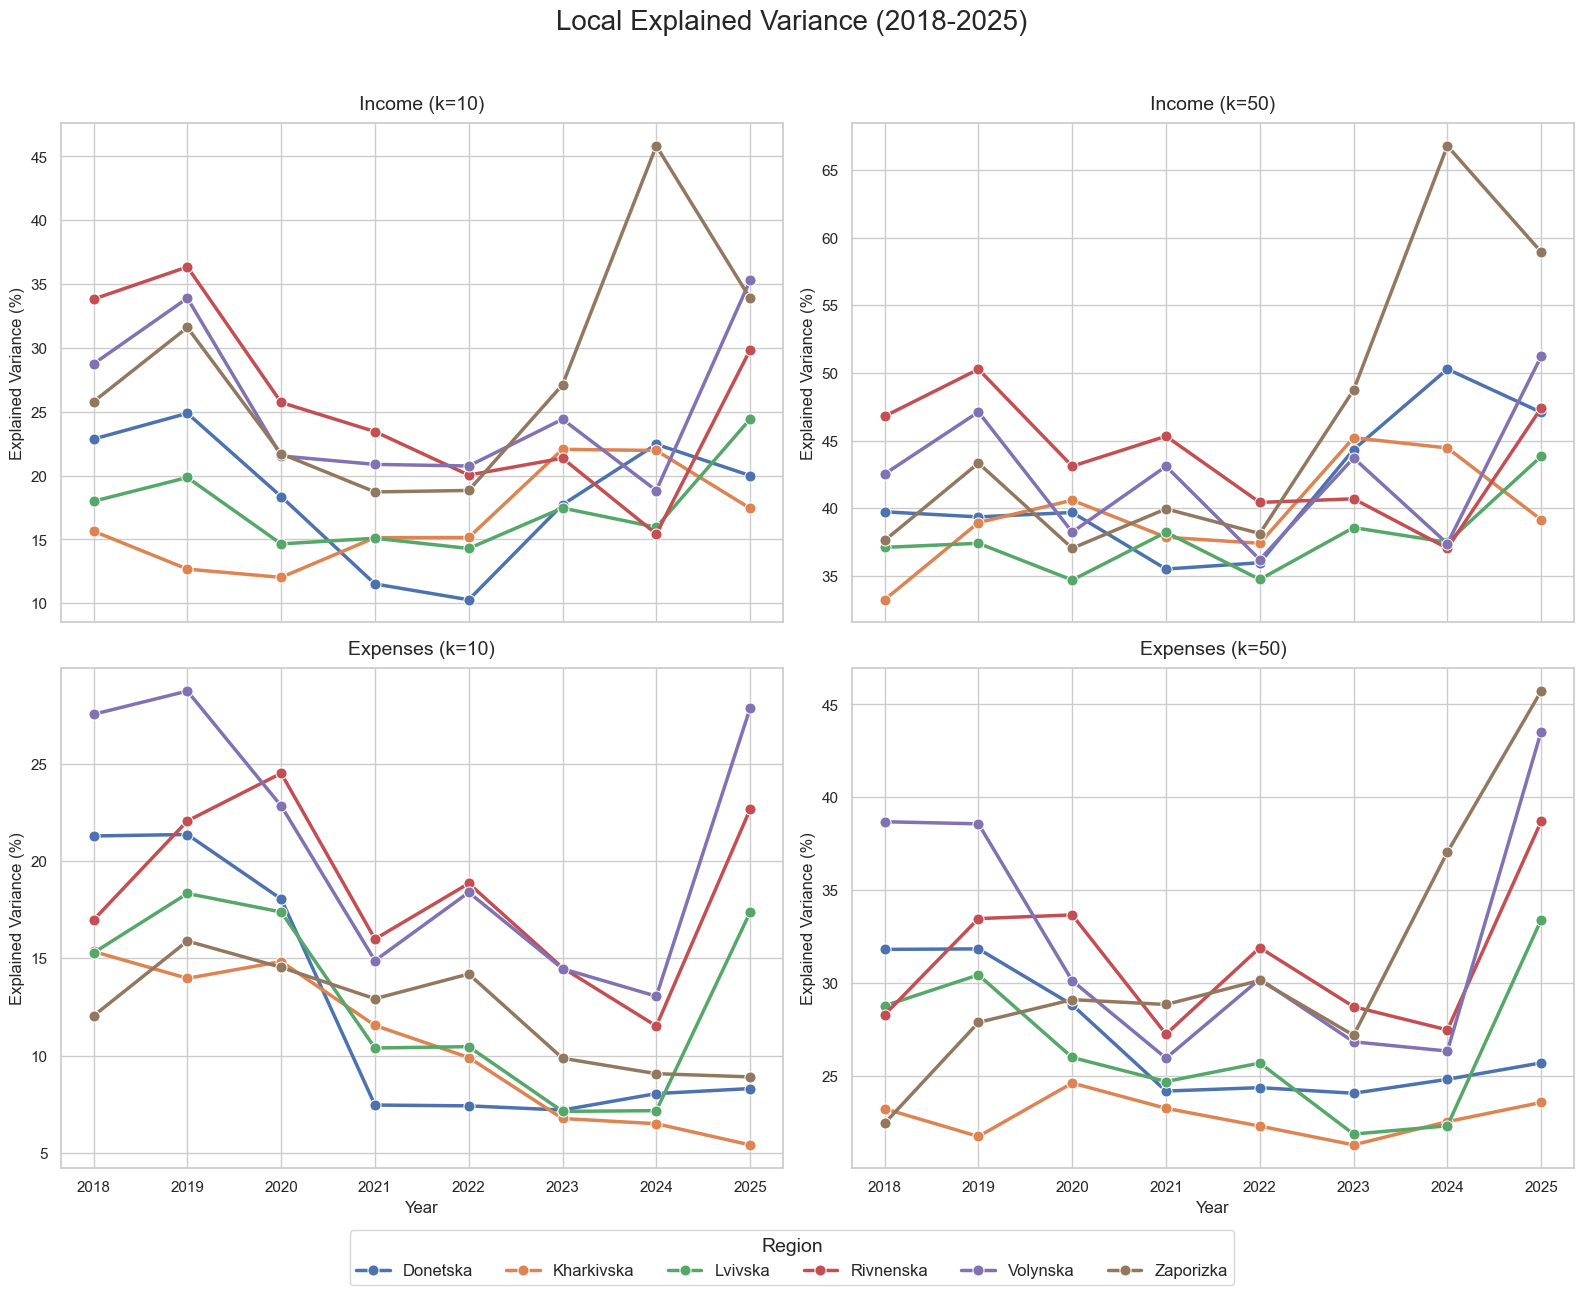

Saved variance_trend_10_50_grid.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = 'all_regions_anomalies_by_year.csv'
TARGET_REGIONS = ['Lvivska', 'Volynska', 'Rivnenska', 'Donetska', 'Zaporizka', 'Kharkivska']
COMPONENTS = [10, 50]
CATEGORIES = ['income', 'prog']
CATEGORY_NAMES = {'income': 'Income', 'prog': 'Expenses'}

df = pd.read_csv(FILE_PATH)

df_filtered = df[df['Region'].isin(TARGET_REGIONS)].copy()
df_filtered['Year'] = pd.to_numeric(df_filtered['Year'])
df_filtered = df_filtered.sort_values(['Category', 'Components', 'Region', 'Year'])

print("=== DATA FOR PLOTS ===")
print(df_filtered[['Category', 'Components', 'Year', 'Region', 'Local_Explained_Var']].to_string(index=False))
print("======================\n")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)

for i, cat in enumerate(CATEGORIES):
    for j, k in enumerate(COMPONENTS):
        ax = axes[i, j]
        
        subset = df_filtered[(df_filtered['Category'] == cat) & (df_filtered['Components'] == k)]
        
        sns.lineplot(
            data=subset, x='Year', y='Local_Explained_Var', hue='Region',
            marker='o', linewidth=2.5, markersize=8, ax=ax
        )
        
        ax.set_title(f'{CATEGORY_NAMES[cat]} (k={k})', fontsize=14, pad=10)
        ax.set_ylabel('Explained Variance (%)', fontsize=12)
        
        if i == len(CATEGORIES) - 1:
            ax.set_xlabel('Year', fontsize=12)
        else:
            ax.set_xlabel('')
            
        ax.set_xticks(subset['Year'].unique())
        
        if ax.get_legend() is not None:
            ax.get_legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Region', title_fontsize='14', fontsize='12',
           loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=6)

plt.suptitle('Local Explained Variance (2018-2025)', fontsize=20, y=1.02)
plt.tight_layout()

plt.savefig('variance_trend_10_50_grid.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved variance_trend_10_50_grid.png")